# 05.04 · Árboles de decisión

**Objetivo:** entender el modelo que se puede **leer en voz alta**. Un árbol de
decisión aprende una cadena de preguntas de sí/no, y el resultado final se puede
imprimir y enseñar a alguien que no sepa nada de matemáticas.

Es también el modelo donde el **sobreajuste** se ve con más claridad que en ningún
otro sitio: un árbol sin podar memoriza el conjunto de entrenamiento entero.

📖 Teoría: [5.1 Modelos clásicos](../../../../../docs/02-deep-learning/05-tipos-de-modelo/5.1-modelos-clasicos.md)
· Para bosques y boosting (juntar muchos árboles) →
[01_02_arboles_bosques_y_boosting](../../01-fundamentos/01-que-es-y-de-donde-viene/01_02_arboles_bosques_y_boosting.py)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

from dllab import set_seed

set_seed(42)

42

## 1. El caso de uso

Un laboratorio de enología recibe botellas sin etiqueta. De cada una tiene el
**análisis químico**: grado alcohólico, acidez, magnesio, intensidad del color, 13
medidas en total. La pregunta: **¿de cuál de las tres bodegas de la región viene este
vino?**

Y hay un requisito añadido, que es el que decide el modelo: **el informe tiene que
explicar el porqué**. Un cliente que recibe un peritaje no acepta "lo dice el
ordenador"; quiere leer el razonamiento.

In [3]:
vino = load_wine()
X, y = vino.data, vino.target

print(f"{X.shape[0]} vinos analizados, {X.shape[1]} medidas químicas cada uno")
print(f"Bodegas: {', '.join(vino.target_names)}")
print(f"Reparto: {np.bincount(y)}")
print("\nAlgunas de las medidas:")
for nombre in vino.feature_names[:6]:
    print(f"  · {nombre}")

178 vinos analizados, 13 medidas químicas cada uno
Bodegas: class_0, class_1, class_2
Reparto: [59 71 48]

Algunas de las medidas:
  · alcohol
  · malic_acid
  · ash
  · alcalinity_of_ash
  · magnesium
  · total_phenols


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"{len(X_train)} vinos para aprender, {len(X_test)} para examinarnos")

124 vinos para aprender, 54 para examinarnos


## 2. La idea en una frase

**Busca la pregunta que mejor parte el grupo en dos, y repite dentro de cada mitad.**

Una "pregunta" es siempre de la forma `¿variable ≤ valor?`. El árbol prueba todas las
variables y todos los cortes posibles, y se queda con el que deja los dos grupos
resultantes **lo más puros posible** — es decir, con más vinos de una sola bodega en
cada lado.

La medida de pureza habitual es la **impureza de Gini**: 0 si en el grupo hay una sola
clase, y sube conforme se mezclan. El árbol siempre elige el corte que más la reduce.

Y entonces repite el proceso en cada mitad. Y otra vez. Hasta que decidas parar.

## 3. Entrenar

Lo limitamos a **3 niveles de profundidad** (`max_depth=3`) para que quepa en pantalla
y se pueda leer. Más adelante veremos qué pasa si lo dejamos crecer sin freno.

In [5]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol.fit(X_train, y_train)

print(f"Acierto en entrenamiento: {arbol.score(X_train, y_train):.1%}")
print(f"Acierto en test         : {arbol.score(X_test, y_test):.1%}")

Acierto en entrenamiento: 99.2%
Acierto en test         : 96.3%


## 4. Leer el modelo

Aquí está lo que ningún otro modelo de este bloque puede ofrecer: **el modelo entero,
dibujado**.

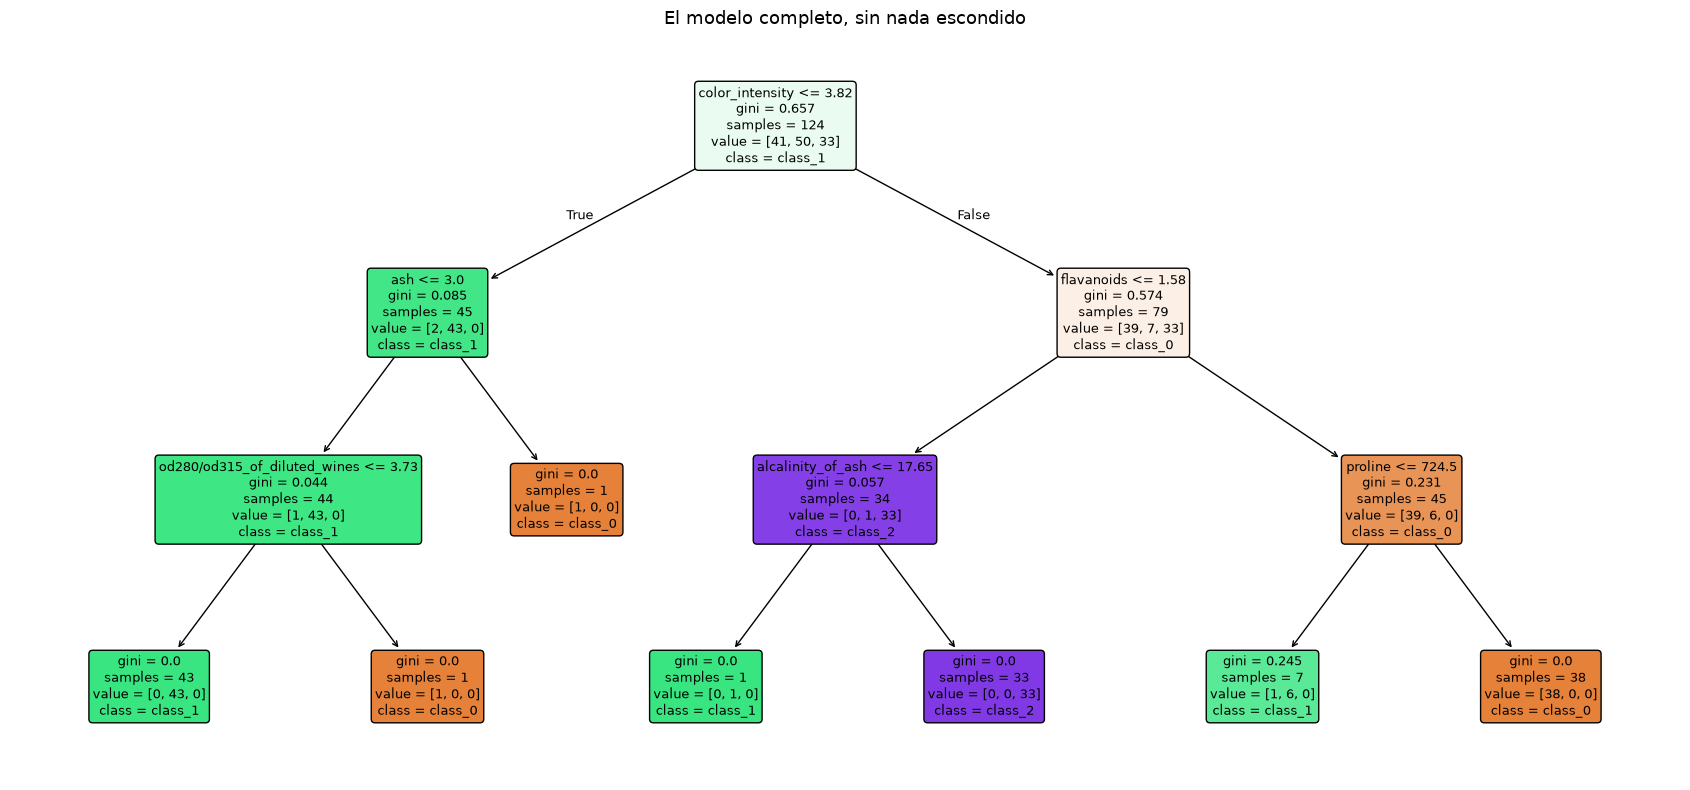

In [6]:
fig, ax = plt.subplots(figsize=(17, 8))
plot_tree(
    arbol,
    feature_names=vino.feature_names,
    class_names=vino.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("El modelo completo, sin nada escondido", fontsize=13)
plt.tight_layout()
plt.show()

Cómo se lee cada caja:

- **primera línea** — la pregunta. Si la respuesta es *sí*, bajas por la izquierda.
- **`gini`** — cuán mezclado está el grupo: 0 significa una sola bodega.
- **`samples`** — cuántos vinos de entrenamiento llegan hasta aquí.
- **`value`** — cómo se reparten esos vinos entre las tres bodegas.
- **el color** — la clase mayoritaria; cuanto más intenso, más puro el grupo.

## 5. El modelo en palabras

El mismo árbol, en texto plano. Esto es lo que se puede pegar en el informe pericial.

In [7]:
print(export_text(arbol, feature_names=list(vino.feature_names)))

|--- color_intensity <= 3.82
|   |--- ash <= 3.00
|   |   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |   |--- class: 1
|   |   |--- od280/od315_of_diluted_wines >  3.73
|   |   |   |--- class: 0
|   |--- ash >  3.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- alcalinity_of_ash <= 17.65
|   |   |   |--- class: 1
|   |   |--- alcalinity_of_ash >  17.65
|   |   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 724.50
|   |   |   |--- class: 1
|   |   |--- proline >  724.50
|   |   |   |--- class: 0



## 6. Seguir una botella concreta por el árbol

Cojamos un vino del conjunto de test y recorramos las preguntas que se le hacen, una
a una, hasta la decisión final.

In [8]:
botella = X_test[0]
prediccion = arbol.predict(botella.reshape(1, -1))[0]

camino = arbol.decision_path(botella.reshape(1, -1)).indices
feature = arbol.tree_.feature
threshold = arbol.tree_.threshold

print(f"Botella nº 0 del test — bodega real: {vino.target_names[y_test[0]]}\n")
print("Recorrido por el árbol:")
for nodo in camino:
    if feature[nodo] == -2:  # hoja
        print(f"  → hoja alcanzada: {vino.target_names[prediccion]}")
        break
    nombre = vino.feature_names[feature[nodo]]
    valor = botella[feature[nodo]]
    if valor <= threshold[nodo]:
        print(f"  ¿{nombre} ≤ {threshold[nodo]:.2f}?  valor={valor:.2f}  → SÍ, por la izquierda")
    else:
        print(f"  ¿{nombre} ≤ {threshold[nodo]:.2f}?  valor={valor:.2f}  → NO, por la derecha")

print(f"\nPredicción: {vino.target_names[prediccion]}")
print(f"Realidad  : {vino.target_names[y_test[0]]}")

Botella nº 0 del test — bodega real: class_0

Recorrido por el árbol:
  ¿color_intensity ≤ 3.82?  valor=5.68  → NO, por la derecha
  ¿flavanoids ≤ 1.58?  valor=3.24  → NO, por la derecha
  ¿proline ≤ 724.50?  valor=1185.00  → NO, por la derecha
  → hoja alcanzada: class_0

Predicción: class_0
Realidad  : class_0


Tres preguntas y una respuesta justificada. Compáralo con explicar por qué una red
neuronal de 10 millones de parámetros ha dicho lo que ha dicho.

## 7. Qué medidas usa de verdad

De las 13 medidas químicas, un árbol de profundidad 3 solo puede usar unas pocas. El
resto ni las mira.

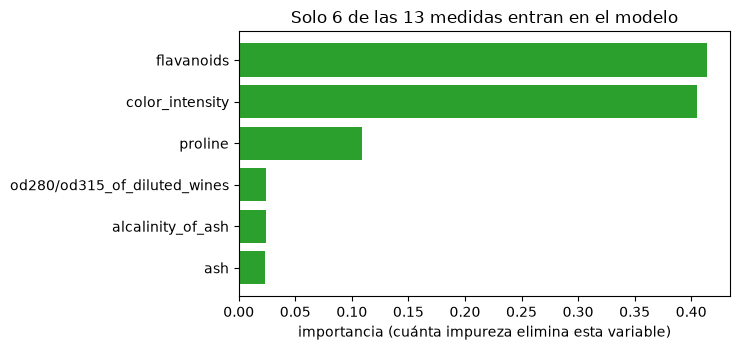

Medidas ignoradas por completo:
  · alcohol
  · malic_acid
  · magnesium
  · total_phenols
  · nonflavanoid_phenols
  · proanthocyanins
  · hue


In [9]:
importancias = arbol.feature_importances_
usadas = np.where(importancias > 0)[0]
orden = usadas[np.argsort(importancias[usadas])]

plt.figure(figsize=(7.5, 3.6))
plt.barh([vino.feature_names[i] for i in orden], importancias[orden], color="tab:green")
plt.xlabel("importancia (cuánta impureza elimina esta variable)")
plt.title(f"Solo {len(usadas)} de las {X.shape[1]} medidas entran en el modelo")
plt.tight_layout()
plt.show()

print("Medidas ignoradas por completo:")
for i in np.where(importancias == 0)[0]:
    print(f"  · {vino.feature_names[i]}")

Esto es **selección de variables gratis**: el árbol te dice, de paso, qué mediciones
podrías dejar de hacer. Si un análisis cuesta dinero, es información valiosa.

## 8. Lo que pasa si lo dejas crecer: sobreajuste en directo

Quitemos el freno. Un árbol sin `max_depth` sigue partiendo hasta que cada hoja
contiene un solo vino. En ese punto **acierta el 100 % en entrenamiento** — y no
porque haya entendido nada, sino porque se ha construido un cajón para cada ejemplo.

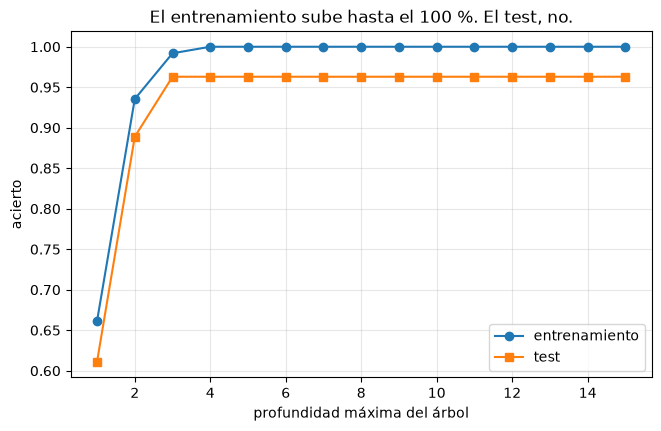

Árbol sin límite — profundidad alcanzada: 4
  entrenamiento: 100.0%
  test         : 96.3%


In [10]:
profundidades = range(1, 16)
acc_train, acc_test = [], []

for d in profundidades:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    acc_train.append(m.score(X_train, y_train))
    acc_test.append(m.score(X_test, y_test))

plt.figure(figsize=(7.5, 4.5))
plt.plot(profundidades, acc_train, marker="o", label="entrenamiento")
plt.plot(profundidades, acc_test, marker="s", label="test")
plt.xlabel("profundidad máxima del árbol")
plt.ylabel("acierto")
plt.title("El entrenamiento sube hasta el 100 %. El test, no.")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

sin_freno = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Árbol sin límite — profundidad alcanzada: {sin_freno.get_depth()}")
print(f"  entrenamiento: {sin_freno.score(X_train, y_train):.1%}")
print(f"  test         : {sin_freno.score(X_test, y_test):.1%}")

La curva de entrenamiento llega a 1,0 y se queda ahí. La de test se estanca mucho
antes y no mejora por seguir creciendo.

**La distancia entre las dos curvas es exactamente el sobreajuste.** Este gráfico es
el que hay que tener en la cabeza cada vez que un modelo dé un resultado sospechosamente
bueno.

Formas de poner freno: `max_depth`, `min_samples_leaf` (mínimo de ejemplos por hoja),
`min_samples_split` o `ccp_alpha` (poda por coste-complejidad).

## 9. La otra debilidad: son inestables

Un árbol es muy sensible a los datos concretos que le toquen. Cambia unas pocas filas
y puede salir un árbol con otras preguntas en la raíz.

In [11]:
print("Variable elegida en la raíz, según la partición de los datos:")
for semilla in range(6):
    Xt, _, yt, _ = train_test_split(X, y, test_size=0.3, random_state=semilla, stratify=y)
    a = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xt, yt)
    raiz = vino.feature_names[a.tree_.feature[0]]
    print(f"  semilla {semilla}: {raiz}")

Variable elegida en la raíz, según la partición de los datos:
  semilla 0: proline
  semilla 1: color_intensity
  semilla 2: color_intensity
  semilla 3: proline
  semilla 4: color_intensity
  semilla 5: alcohol


Esa inestabilidad es justamente el motivo por el que existen los **bosques
aleatorios** y el **boosting**: si un árbol solo es tan variable, entrena muchos sobre
muestras distintas y promedia. El error individual se cancela y la precisión sube
muchísimo — a cambio de perder la lectura directa que acabamos de hacer.

Ese camino está desarrollado en
[01_02_arboles_bosques_y_boosting](../../01-fundamentos/01-que-es-y-de-donde-viene/01_02_arboles_bosques_y_boosting.py).

## 10. Cuándo usarlo y cuándo no

**Úsalo cuando:**

- Hay que **justificar** la decisión ante un cliente, un auditor o un regulador.
- Los datos mezclan variables numéricas y categóricas, o tienen escalas dispares: al
  árbol le da igual, solo compara valores dentro de cada columna. **No necesita
  escalado** (al revés que [k-NN](05_03_knn.py) o [SVM](05_02_svm_y_kernels.py)).
- Quieres una primera lectura de qué variables importan.

**No lo uses cuando:**

- Buscas la máxima precisión: un árbol solo casi siempre pierde contra un bosque o un
  boosting.
- La frontera real es diagonal o curva. Un árbol solo corta en horizontal y vertical,
  así que aproxima una diagonal a base de escalones.
- Los datos son imágenes, audio o texto sin procesar.

## 11. Prueba tú

1. Pon `max_depth=2`. ¿Cuánto acierto pierdes a cambio de un árbol de dos preguntas?
2. Prueba `min_samples_leaf=10` sin límite de profundidad. ¿Frena el sobreajuste?
3. Cambia `criterion="entropy"`. ¿Sale el mismo árbol que con Gini?
4. Entrena solo con las 2 variables más importantes y dibuja la frontera de decisión
   en el plano (puedes reutilizar la función `dibujar_frontera` de
   [05_03_knn](05_03_knn.py)). ¿Ves los escalones?